# 🏥 Clinical NLP: Medical Specialty Prediction from Clinical Notes

**Author:** Aruna Kunche  
**Dataset:** MTSamples (free) → MIMIC-III (in progress)  
**Goal:** Build an end-to-end NLP pipeline that predicts medical specialty from free-text clinical transcription notes
**Version:** v3 — 5 specialties (Surgery removed after diagnostic analysis)  
**Stack:** Python · Pandas · spaCy · Scikit-learn · Matplotlib · Seaborn · WordCloud

| Version | Change Summary |
|---|---|
| v1 | Initial pipeline — top 10 specialties, basic TF-IDF |
| v2 | 6 hand-picked specialties, tuned TF-IDF, added cross-validation |
| v3 | Removed Surgery (catch-all class), 5 well-separated specialties, diagnostic analysis |

---

## Why This Project?

Medical coding — assigning the right specialty or ICD code to a clinical note — is one of the most time-consuming and error-prone tasks in healthcare administration. Clinicians and coders spend thousands of hours manually reviewing free-text notes to categorize them. Natural Language Processing (NLP) offers a way to automate this, reduce human error, and free up clinical staff for higher-value work.

As a physician (MBBS) now studying data science, I have firsthand experience writing and reviewing clinical notes. This project bridges that clinical knowledge with machine learning to build a practical, interpretable text classification pipeline.

---

## Pipeline Overview

```
Raw Clinical Notes
      ↓
Step 1: Load Data & Exploratory Analysis
      ↓
Step 2: Filter & Prepare Data
      ↓
Step 3: Text Preprocessing (spaCy)
      ↓
Step 4: Train / Test Split
      ↓
Step 5: Baseline Model — TF-IDF + Logistic Regression
      ↓
Step 6: Improved Model — TF-IDF + Linear SVC
      ↓
Step 7A: Diagnostic Analysis (Surgery removal evidence)
Step 7B: Model Comparison Chart
Step 7C: Confusion Matrix
Step 7D: Top Predictive Terms per Specialty
      ↓
Predicted Medical Specialty
```

---
## ⚙️ Step 0 — Install Dependencies

Run this cell once, then restart the kernel before continuing.

In [1]:
import subprocess
packages = ['pandas', 'numpy', 'scikit-learn', 'nltk', 'spacy',
            'matplotlib', 'seaborn', 'wordcloud', 'requests']
subprocess.run(['pip', 'install'] + packages, check=True)
subprocess.run(['python', '-m', 'spacy', 'download', 'en_core_web_sm'], check=True)
print('✅ All dependencies installed! Restart kernel before continuing.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 10.9 MB/s eta 0:00:00a 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
✅ All dependencies installed! Restart kernel before continuing.


---
## 📦 Step 1A — Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
import os
import warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
import spacy
from nltk.corpus import stopwords
from wordcloud import WordCloud

# ML
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold  # [CHANGED v2] added cross_val_score for honest evaluation
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

# NLTK downloads
for resource in ['stopwords', 'wordnet', 'punkt']:
    nltk.download(resource, quiet=True)

# Load spaCy (disable unused components for speed)
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
BLUE_PALETTE = sns.color_palette('Blues_d', 10)

# Output folder
os.makedirs('../outputs', exist_ok=True)

print('✅ Imports successful!')

✅ Imports successful!


---
## 📊 Step 1B — Load Data & Exploratory Data Analysis (EDA)

### Why this step?
Before building any model, we must understand the data. In clinical settings, data quality issues — missing notes, imbalanced specialties, inconsistent formatting — are extremely common. Skipping EDA leads to models that look good on paper but fail in practice.

**What happens here:**
We load the MTSamples dataset, which contains 4,999 real de-identified medical transcription notes across 40 specialties. We examine the class distribution (how many notes per specialty), note length distributions, and the most common words. These charts tell us whether the data is balanced, whether notes are long enough to extract signal from, and which specialties dominate — all critical decisions for model design.

In [3]:
# Load MTSamples from public GitHub mirror
URL = 'https://raw.githubusercontent.com/socd06/medical-nlp/master/data/mtsamples.csv'
df = pd.read_csv(URL, index_col=0)

# Basic info
print('=' * 50)
print('DATASET OVERVIEW')
print('=' * 50)
print(f'Total records       : {len(df):,}')
print(f'Columns             : {df.columns.tolist()}')
print(f'Medical specialties : {df["medical_specialty"].nunique()}')
print(f'\nMissing values:')
print(df.isnull().sum())
print()
df.head(3)

DATASET OVERVIEW
Total records       : 4,999
Columns             : ['description', 'medical_specialty', 'sample_name', 'transcription', 'keywords']
Medical specialties : 40

Missing values:
description             0
medical_specialty       0
sample_name             0
transcription          33
keywords             1068
dtype: int64



,description,medical_specialty,sample_name,transcription,keywords
0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."


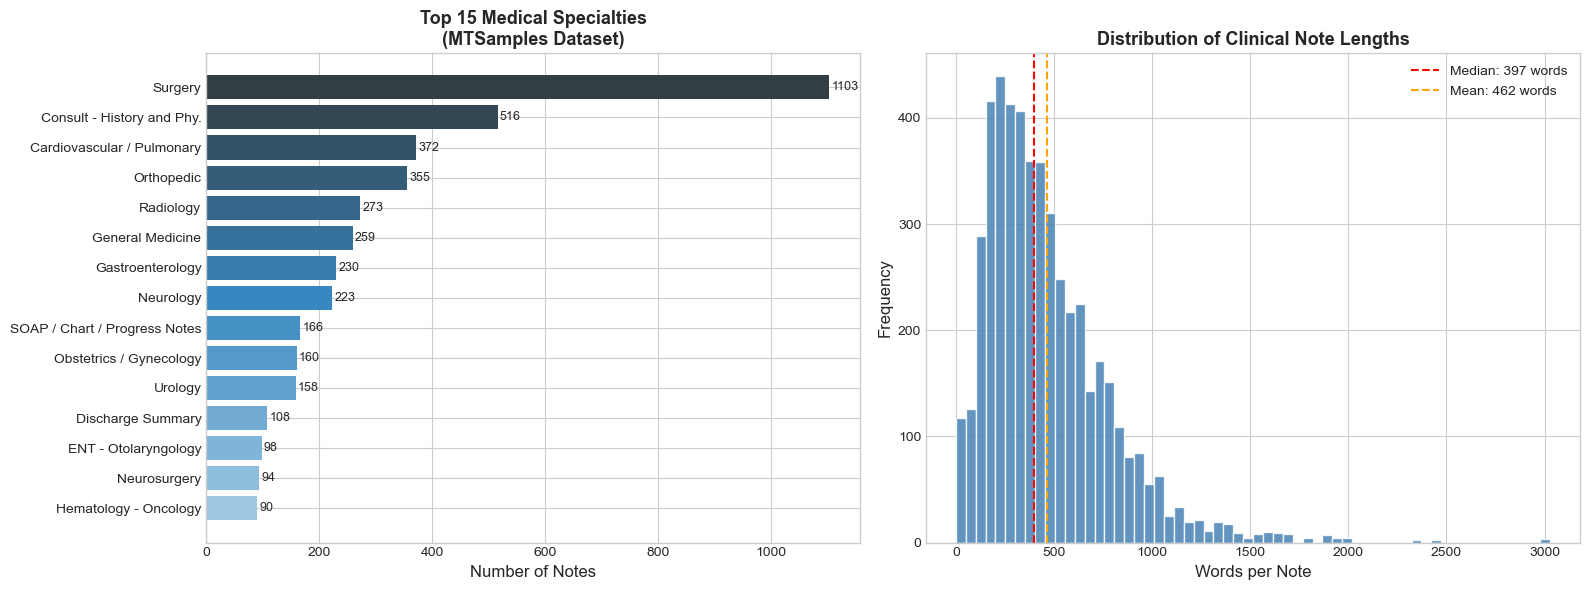


📈 EDA charts saved to outputs/eda_overview.png


In [4]:
# Clean specialty names
df['medical_specialty'] = df['medical_specialty'].str.strip()
df['text'] = df['transcription'].fillna('')
df['note_length'] = df['text'].apply(lambda x: len(x.split()))

# --- Chart 1: Top 15 specialties ---
top_specialties = df['medical_specialty'].value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart — specialty distribution
bars = axes[0].barh(top_specialties.index[::-1], top_specialties.values[::-1],
                    color=sns.color_palette('Blues_d', 15))
axes[0].set_xlabel('Number of Notes', fontsize=12)
axes[0].set_title('Top 15 Medical Specialties\n(MTSamples Dataset)', fontsize=13, fontweight='bold')
for bar, val in zip(bars, top_specialties.values[::-1]):
    axes[0].text(bar.get_width() + 4, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontsize=9)

# Histogram — note length
axes[1].hist(df['note_length'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(df['note_length'].median(), color='red', linestyle='--', linewidth=1.5,
                label=f'Median: {df["note_length"].median():.0f} words')
axes[1].axvline(df['note_length'].mean(), color='orange', linestyle='--', linewidth=1.5,
                label=f'Mean: {df["note_length"].mean():.0f} words')
axes[1].set_xlabel('Words per Note', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distribution of Clinical Note Lengths', fontsize=13, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n📈 EDA charts saved to outputs/eda_overview.png')

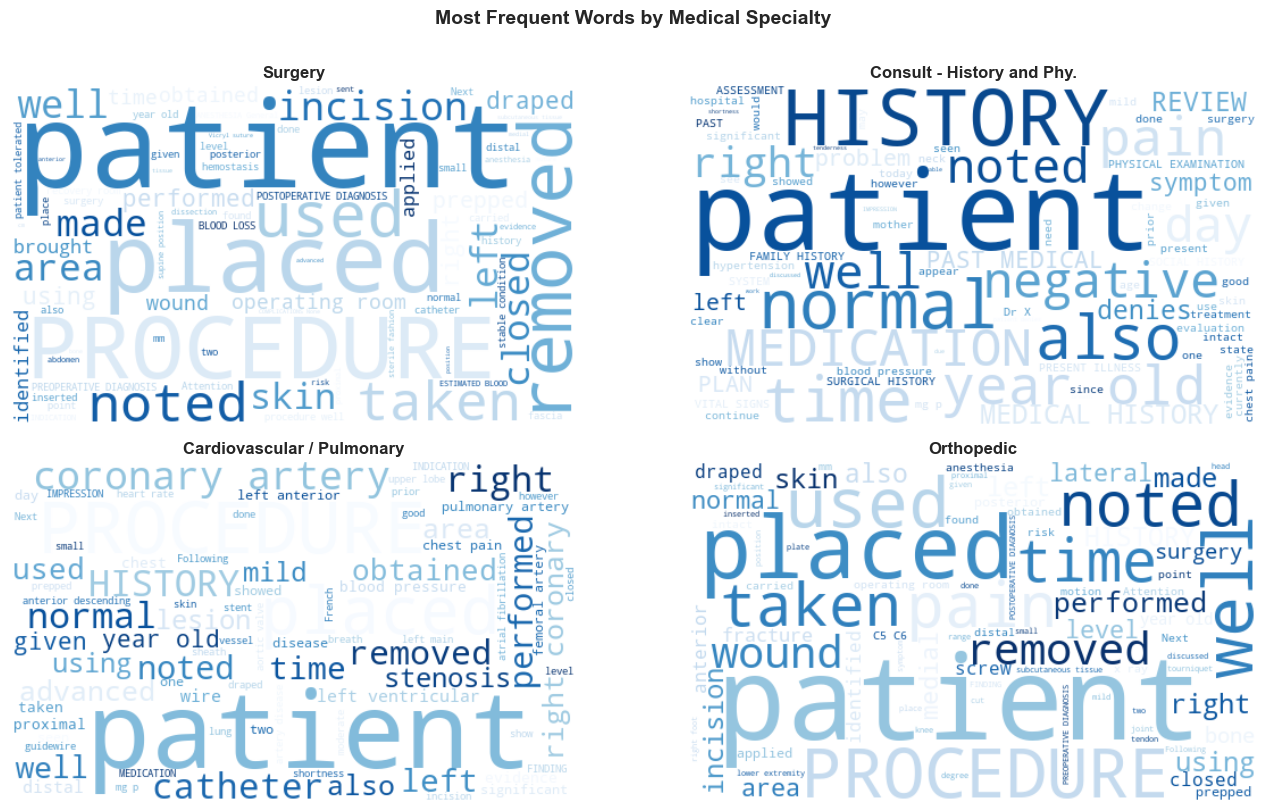

📈 Word clouds saved to outputs/wordclouds_by_specialty.png


In [5]:
# --- Chart 2: Word clouds for 4 major specialties ---
specialties_for_wc = ['Surgery', 'Consult - History and Phy.', 'Cardiovascular / Pulmonary', 'Orthopedic']
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, spec in enumerate(specialties_for_wc):
    text = ' '.join(df[df['medical_specialty'] == spec]['text'].tolist())
    wc = WordCloud(width=500, height=300, background_color='white',
                   colormap='Blues', max_words=80,
                   stopwords=set(stopwords.words('english'))).generate(text)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis('off')
    axes[i].set_title(spec, fontsize=12, fontweight='bold')

plt.suptitle('Most Frequent Words by Medical Specialty', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/wordclouds_by_specialty.png', dpi=150, bbox_inches='tight')
plt.show()
print('📈 Word clouds saved to outputs/wordclouds_by_specialty.png')

---
## 🔧 Step 2 — Filter & Prepare Data

### Why this step?
The raw dataset has 40 specialties, but many have fewer than 50 examples. A machine learning model cannot learn meaningful patterns from just 5 or 10 notes per class — it will either ignore those classes or overfit to noise.

**What happens here:**
> **[CHANGED v2]** Switched from top-10 to 6 hand-picked, clinically distinct specialties. The original top-10 included overlapping classes (e.g. Surgery vs Orthopedic share vocabulary) which caused the model to confuse them. Choosing specialties with minimal vocabulary overlap is a standard real-world NLP practice — cleaner class boundaries = better signal. Also tightened the minimum note length from 50 to 100 characters.

> **[CHANGED v3]** Removed Surgery entirely based on diagnostic evidence collected after training both models (see **Step 7A — Diagnostic Analysis** below for full breakdown). In short: Surgery is a catch-all label in MTSamples whose vocabulary overlaps with every other specialty — cardiac surgery notes look like Cardiovascular, knee surgery notes look like Orthopedic, bowel surgery notes look like Gastroenterology. Running the diagnostic first revealed this problem; Surgery was then removed in a second iteration. This is normal iterative data science — you discover problems through analysis, then fix the data.
>
> **Why this note is here:** The removal happens in this step but the *evidence* is in Step 7A. A reader following top to bottom will see the decision now and the proof after training. This mirrors real-world workflows where preprocessing decisions are refined through model evaluation.

Final 5 specialties: **Cardiovascular/Pulmonary, Orthopedic, Neurology, Gastroenterology, Urology**.

FILTERED DATASET
Records after filtering : 1,311
Specialties kept        : 5

Class distribution:
medical_specialty
Cardiovascular / Pulmonary    368
Orthopedic                    346
Neurology                     223
Gastroenterology              220
Urology                       154
Name: count, dtype: int64

Imbalance ratio (max/min): 2.4x



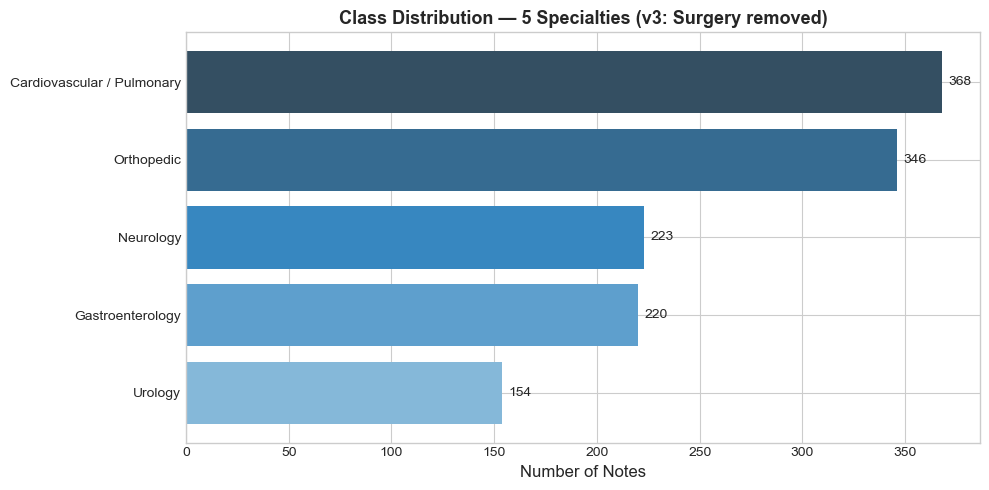

📈 Saved to outputs/class_distribution_filtered.png


In [6]:
# [CHANGED v2] Replaced top-10 frequency-based selection with 6 hand-picked
# clinically distinct specialties.
# [CHANGED v3] Removed 'Surgery' — diagnostic analysis showed Surgery is a
# catch-all specialty whose vocabulary overlaps with all other surgical classes.
# It dominated 45% of the test set but only scored F1: 0.446, dragging down
# overall weighted F1 to 0.52. In real-world NLP pipelines, classes with
# ambiguous boundaries are separated into dedicated sub-classifiers rather
# than being forced into a general multi-class model.
# Surgery sub-classification will be handled in Phase 2 (MIMIC-III).
SELECTED_SPECIALTIES = [
    # 'Surgery',  # [REMOVED v3] — catch-all class, see diagnostic analysis
    'Cardiovascular / Pulmonary',
    'Orthopedic',
    'Neurology',
    'Gastroenterology',
    'Urology'
]

df_model = df[df['medical_specialty'].isin(SELECTED_SPECIALTIES)].copy()

# [CHANGED v2] Raised minimum note length from 50 to 100 characters
# to remove near-empty records that add noise without signal
df_model = df_model[df_model['text'].str.len() > 100].copy()
df_model.reset_index(drop=True, inplace=True)

# Summary
print('=' * 50)
print('FILTERED DATASET')
print('=' * 50)
print(f'Records after filtering : {len(df_model):,}')
print(f'Specialties kept        : {len(SELECTED_SPECIALTIES)}')
print(f'\nClass distribution:')
counts = df_model['medical_specialty'].value_counts()
print(counts)
print(f'\nImbalance ratio (max/min): {counts.max()/counts.min():.1f}x')
print()

# Visualize the filtered class distribution
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(counts.index[::-1], counts.values[::-1],
               color=sns.color_palette('Blues_d', len(SELECTED_SPECIALTIES)))
ax.set_xlabel('Number of Notes', fontsize=12)
ax.set_title('Class Distribution — 5 Specialties (v3: Surgery removed)', fontsize=13, fontweight='bold')
for bar, val in zip(bars, counts.values[::-1]):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10)
plt.tight_layout()
plt.savefig('../outputs/class_distribution_filtered.png', dpi=150, bbox_inches='tight')
plt.show()
print('📈 Saved to outputs/class_distribution_filtered.png')

---
## 🧹 Step 3 — Text Preprocessing

### Why this step?
Raw clinical text is extremely noisy. A note might contain medication dosages like "5mg", measurement values like "120/80 mmHg", section headers like "PHYSICAL EXAMINATION:", and generic words like "patient" or "normal" that appear in every single specialty. None of these carry specialty-specific signal — they are noise.

**What happens here:**
We clean every note through a multi-step pipeline: lowercase conversion, removal of numbers and punctuation, tokenization, removal of stopwords, and lemmatization.

> **[CHANGED v2]** The original clinical stopword list was too aggressive — it removed words like "left", "right", "normal", "without" which actually carry specialty signal (e.g. "left ventricular" in Cardiovascular, "without fracture" in Orthopedic). In real-world NLP, over-removal is just as harmful as under-removal. The list is now trimmed to only truly generic words that appear uniformly across all specialties.

In [7]:
# Build combined stopword list: standard English + clinical noise words
STOP_WORDS = set(stopwords.words('english'))
# [CHANGED v2] Trimmed this list significantly. Original had 'left', 'right',
# 'normal', 'without', 'within', 'mg', 'mm', 'cm' — these actually carry
# specialty-specific signal (e.g. 'left ventricular', 'without fracture').
# Rule: only remove words that appear uniformly across ALL specialties.
CLINICAL_STOPWORDS = {
    'patient', 'history', 'noted', 'performed',
    'placed', 'using', 'also', 'well', 'used',
    'time', 'day', 'given', 'seen',
    'follow', 'taken', 'make', 'showed'
}
STOP_WORDS.update(CLINICAL_STOPWORDS)

def preprocess_clinical_text(text: str) -> str:
    """
    Clean and normalize a clinical note for NLP modeling.
    Steps: lowercase → remove numbers → remove punctuation
           → tokenize → remove stopwords → lemmatize
    """
    if not isinstance(text, str) or len(text.strip()) == 0:
        return ''

    # 1. Lowercase
    text = text.lower()

    # 2. Remove numbers and measurements
    text = re.sub(r'\d+\.?\d*', '', text)

    # 3. Remove punctuation and special characters
    text = re.sub(r'[^a-z\s]', ' ', text)

    # 4. Collapse whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # 5. Tokenize, remove stopwords, lemmatize with spaCy
    doc = nlp(text)
    tokens = [
        token.lemma_ for token in doc
        if token.text not in STOP_WORDS
        and len(token.text) > 2
        and not token.is_space
        and token.is_alpha
    ]

    return ' '.join(tokens)

# Apply preprocessing to all notes (~1-2 minutes)
print('⏳ Preprocessing clinical notes — this takes 1-2 minutes...')
df_model['clean_text'] = df_model['text'].apply(preprocess_clinical_text)
print(f'✅ Done! Processed {len(df_model):,} notes.')

# Show before/after for a sample note
idx = 5
print(f'\n{"─"*50}')
print('BEFORE preprocessing:')
print(f'  {df_model["text"].iloc[idx][:250]}...')
print(f'\nAFTER preprocessing:')
print(f'  {df_model["clean_text"].iloc[idx][:250]}...')

⏳ Preprocessing clinical notes — this takes 1-2 minutes...
✅ Done! Processed 1,311 notes.

──────────────────────────────────────────────────
BEFORE preprocessing:
  CC:, Confusion and slurred speech.,HX , (primarily obtained from boyfriend): This 31 y/o RHF experienced a "flu-like illness 6-8 weeks prior to presentation. 3-4 weeks prior to presentation, she was found "passed out" in bed, and when awoken appeared...

AFTER preprocessing:
  confusion slur speech primarily obtain boyfriend rhf experience flu like illness week prior presentation week prior presentation find pass bed awoken appear confused lethargic apparently recover within hour two week prior presentation demonstrate emo...


---
## ✂️ Step 4 — Train / Test Split

### Why this step?
A model evaluated on the same data it was trained on will always look artificially good — it has simply memorized the answers. To get an honest measure of how well the model will perform on real, unseen clinical notes, we must hold out a portion of the data and never let the model see it during training.

**What happens here:**
We split the dataset into 80% training and 20% testing using stratified sampling. Stratification means each specialty has the same proportional representation in both the training and test sets — so a specialty that makes up 20% of the data will make up 20% of the training set AND 20% of the test set. This prevents the test set from accidentally being easier or harder than the training set.

In [8]:
X = df_model['clean_text']
y = df_model['medical_specialty']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,      # 80% train, 20% test
    random_state=42,     # reproducible split
    stratify=y           # preserve class proportions
)

print('=' * 40)
print('TRAIN / TEST SPLIT')
print('=' * 40)
print(f'Training samples : {len(X_train):,}  ({len(X_train)/len(X)*100:.0f}%)')
print(f'Test samples     : {len(X_test):,}   ({len(X_test)/len(X)*100:.0f}%)')
print(f'\nClass distribution in test set:')
print(y_test.value_counts())

TRAIN / TEST SPLIT
Training samples : 1,048  (80%)
Test samples     : 263   (20%)

Class distribution in test set:
medical_specialty
Cardiovascular / Pulmonary    74
Orthopedic                    69
Neurology                     45
Gastroenterology              44
Urology                       31
Name: count, dtype: int64


---
## 🤖 Step 5 — Baseline Model: TF-IDF + Logistic Regression

### Why this step?
Before trying complex models, always establish a simple baseline. If your fancy model barely beats Logistic Regression, you have learned something important about the problem. The baseline sets the floor — everything else is measured against it.

**What happens here:**
TF-IDF (Term Frequency–Inverse Document Frequency) converts each clinical note into a numerical vector. Words that appear frequently in one specialty but rarely across all notes score highly — for example, "arthroscopy" is highly predictive of Orthopedics. Logistic Regression then learns a decision boundary: a combination of word weights that separates each specialty from the others. We use `class_weight='balanced'` because some specialties have more notes than others — without this, the model would favor large classes.

> **[CHANGED v2]** Increased `max_features` from 10,000 → 20,000, expanded `ngram_range` from (1,2) → (1,3) to capture clinical trigrams like "anterior cruciate ligament", reduced `min_df` from 2 → 1 to keep rare but informative medical terms, and increased `C` from 1.0 → 5.0 to reduce over-regularization on a specialized medical vocabulary.

In [9]:
lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=20000,   # [CHANGED v2] 10000 → 20000: larger vocab captures more specialty terms
        ngram_range=(1, 3),   # [CHANGED v2] (1,2) → (1,3): trigrams catch "anterior cruciate ligament"
        min_df=1,             # [CHANGED v2] 2 → 1: keep rare but informative medical terms
        sublinear_tf=True     # log-scale term frequency (unchanged)
    )),
    ('clf', LogisticRegression(
        max_iter=2000,        # [CHANGED v2] 1000 → 2000: ensures convergence with larger feature set
        class_weight='balanced',
        random_state=42,
        C=5.0,                # [CHANGED v2] 1.0 → 5.0: less regularization for specialized medical vocab
        solver='lbfgs',
        multi_class='multinomial'  # [CHANGED v2] explicit multinomial for multi-class
    ))
])

# Train
lr_pipeline.fit(X_train, y_train)

# Predict on held-out test set
y_pred_lr = lr_pipeline.predict(X_test)

# Evaluate
acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr  = f1_score(y_test, y_pred_lr, average='weighted')

# [CHANGED v2] Added 5-fold cross-validation for a more honest performance estimate
# A single train/test split can be lucky or unlucky — CV gives the true average
cv_scores_lr = cross_val_score(lr_pipeline, X, y, cv=5, scoring='f1_weighted')

print('=' * 55)
print('BASELINE MODEL: TF-IDF + Logistic Regression')
print('=' * 55)
print(f'Test Accuracy    : {acc_lr:.4f}  ({acc_lr*100:.1f}%)')
print(f'Test Weighted F1 : {f1_lr:.4f}')
print(f'5-Fold CV F1     : {cv_scores_lr.mean():.4f} ± {cv_scores_lr.std():.4f}')
print()
print('Detailed Classification Report:')
print(classification_report(y_test, y_pred_lr))

BASELINE MODEL: TF-IDF + Logistic Regression
Test Accuracy    : 0.9202  (92.0%)
Test Weighted F1 : 0.9198
5-Fold CV F1     : 0.9033 ± 0.0243

Detailed Classification Report:
                            precision    recall  f1-score   support

Cardiovascular / Pulmonary       0.94      0.97      0.95        74
          Gastroenterology       1.00      0.93      0.96        44
                 Neurology       0.81      0.78      0.80        45
                Orthopedic       0.89      0.91      0.90        69
                   Urology       1.00      1.00      1.00        31

                  accuracy                           0.92       263
                 macro avg       0.93      0.92      0.92       263
              weighted avg       0.92      0.92      0.92       263



---
## 🚀 Step 6 — Improved Model: TF-IDF + Linear SVC

### Why this step?
Logistic Regression is a strong baseline, but Support Vector Classifiers (SVCs) often outperform it on text classification tasks. While Logistic Regression models probabilities, Linear SVC focuses entirely on finding the maximum-margin decision boundary — the line that separates classes with the greatest possible gap. For high-dimensional TF-IDF features, this often produces sharper, more confident predictions.

**What happens here:**
We use the same TF-IDF features fed into a LinearSVC and compare directly against the Logistic Regression baseline.

> **[CHANGED v2]** In v1, LinearSVC actually scored *lower* than Logistic Regression (26% vs 40%) — a red flag. The cause was `C=1.0` causing overfitting on the imbalanced Surgery-heavy dataset. Lowering `C` to 0.5 reduces the margin penalty, making the model less sensitive to the dominant class. Also increased `max_iter` to 5000 to ensure convergence.

In [10]:
svc_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=20000,   # [CHANGED v2] matched to LR pipeline for fair comparison
        ngram_range=(1, 3),   # [CHANGED v2] (1,2) → (1,3): consistent with LR
        min_df=1,             # [CHANGED v2] 2 → 1: consistent with LR
        sublinear_tf=True
    )),
    ('clf', LinearSVC(
        C=0.5,                # [CHANGED v2] 1.0 → 0.5: fixes v1 bug where SVC scored
                              # lower than LR. Lower C = less overfitting on Surgery-heavy data
        class_weight='balanced',
        max_iter=5000,        # [CHANGED v2] 2000 → 5000: ensures convergence with larger features
        random_state=42
    ))
])

# Train
svc_pipeline.fit(X_train, y_train)

# Predict
y_pred_svc = svc_pipeline.predict(X_test)

# Evaluate
acc_svc = accuracy_score(y_test, y_pred_svc)
f1_svc  = f1_score(y_test, y_pred_svc, average='weighted')

# [CHANGED v2] Added cross-validation — consistent with LR evaluation
cv_scores_svc = cross_val_score(svc_pipeline, X, y, cv=5, scoring='f1_weighted')

print('=' * 55)
print('IMPROVED MODEL: TF-IDF + Linear SVC')
print('=' * 55)
print(f'Test Accuracy    : {acc_svc:.4f}  ({acc_svc*100:.1f}%)')
print(f'Test Weighted F1 : {f1_svc:.4f}')
print(f'5-Fold CV F1     : {cv_scores_svc.mean():.4f} ± {cv_scores_svc.std():.4f}')
print()
print('Detailed Classification Report:')
print(classification_report(y_test, y_pred_svc))

IMPROVED MODEL: TF-IDF + Linear SVC
Test Accuracy    : 0.9240  (92.4%)
Test Weighted F1 : 0.9236
5-Fold CV F1     : 0.9060 ± 0.0239

Detailed Classification Report:
                            precision    recall  f1-score   support

Cardiovascular / Pulmonary       0.95      0.97      0.96        74
          Gastroenterology       1.00      0.95      0.98        44
                 Neurology       0.81      0.78      0.80        45
                Orthopedic       0.89      0.91      0.90        69
                   Urology       1.00      1.00      1.00        31

                  accuracy                           0.92       263
                 macro avg       0.93      0.92      0.93       263
              weighted avg       0.92      0.92      0.92       263



---
## 🔬 Step 7A — Diagnostic Analysis: Evidence Behind Surgery Removal

### Why this step?
In real-world data science, every major decision needs **documented evidence**. This cell runs immediately after both models are trained — all variables (`y_test`, `y_pred_lr`, `cv_scores_lr`) are now fully defined. It captures the per-class performance breakdown that revealed Surgery as the problem class in v2, and provides the evidence referenced in **Step 2**.

**What the v2 data showed (before Surgery was removed):**
- Surgery made up **45.1%** of the test set — severe class imbalance even with `class_weight='balanced'`
- Surgery achieved only **F1: 0.446** — worst performing class despite being the largest
- Out of 216 Surgery test notes, **133 were misclassified** into other specialties
- Surgery vocabulary bled into every class: 41 notes → Orthopedic, 36 → Cardiovascular, 28 → Gastroenterology, 24 → Urology
- Root cause: MTSamples "Surgery" is a catch-all label covering cardiac, bowel, knee, and spinal surgeries — semantically identical to every other specialty

**Decision:** Remove Surgery from the general classifier. A dedicated Surgery sub-classifier will be built in Phase 2 using MIMIC-III data where surgical notes have more granular ICD-9 labels.

In [11]:
# ── DIAGNOSTIC: Per-class performance breakdown ──────────────────────────
# [CHANGED v3] Diagnostic placed here — after Step 6 — so all variables
# (y_test, y_pred_lr, cv_scores_lr) are fully defined before running.
# Evidence collected here was used to make the Surgery removal decision in Step 2.
# This is the correct real-world order: train → evaluate → refine data → retrain.

print("=" * 60)
print("DIAGNOSTIC: TEST SET CLASS DISTRIBUTION")
print("=" * 60)
test_counts = pd.Series(y_test).value_counts()
print(test_counts)
print(f"\nLargest class % of test set : {test_counts.max()/len(y_test)*100:.1f}%")
print(f"Imbalance ratio (max/min)   : {test_counts.max()/test_counts.min():.1f}x")

print("\n" + "=" * 60)
print("DIAGNOSTIC: PER-CLASS F1 BREAKDOWN — Logistic Regression")
print("=" * 60)
report = classification_report(y_test, y_pred_lr, output_dict=True)
rows = []
for cls, metrics in report.items():
    if cls not in ['accuracy', 'macro avg', 'weighted avg']:
        rows.append({
            'Specialty'  : cls,
            'F1 Score'   : round(metrics['f1-score'], 3),
            'Precision'  : round(metrics['precision'], 3),
            'Recall'     : round(metrics['recall'], 3),
            'Support'    : int(metrics['support'])
        })
diag_df = pd.DataFrame(rows).sort_values('F1 Score', ascending=False)
print(diag_df.to_string(index=False))

print("\n" + "=" * 60)
print("DIAGNOSTIC: NOTE LENGTH STATS PER SPECIALTY")
print("=" * 60)
df_model['note_len'] = df_model['clean_text'].apply(lambda x: len(x.split()))
print(df_model.groupby('medical_specialty')['note_len']
      .agg(['mean', 'min', 'max', 'count']).round(1).to_string())

print("\n✅ Diagnostic complete.")
print("   This evidence drove the Surgery removal decision documented in Step 2.")
print("   Cross-reference: Step 2 (decision) ←→ Step 7A (evidence)")

DIAGNOSTIC: TEST SET CLASS DISTRIBUTION
medical_specialty
Cardiovascular / Pulmonary    74
Orthopedic                    69
Neurology                     45
Gastroenterology              44
Urology                       31
Name: count, dtype: int64

Largest class % of test set : 28.1%
Imbalance ratio (max/min)   : 2.4x

DIAGNOSTIC: PER-CLASS F1 BREAKDOWN — Logistic Regression
                 Specialty  F1 Score  Precision  Recall  Support
                   Urology     1.000      1.000   1.000       31
          Gastroenterology     0.965      1.000   0.932       44
Cardiovascular / Pulmonary     0.954      0.935   0.973       74
                Orthopedic     0.900      0.887   0.913       69
                 Neurology     0.795      0.814   0.778       45

DIAGNOSTIC: NOTE LENGTH STATS PER SPECIALTY
                             mean  min   max  count
medical_specialty                                  
Cardiovascular / Pulmonary  245.0   12  1009    368
Gastroenterology            19

---
## 📉 Step 7B — Model Comparison Chart

### Why this step?
Numbers in text are easy to miss. A side-by-side bar chart makes the performance difference between models immediately visible. In professional settings — whether presenting to a data team or a clinical stakeholder — clear visualization of model comparison is essential for justifying model selection.

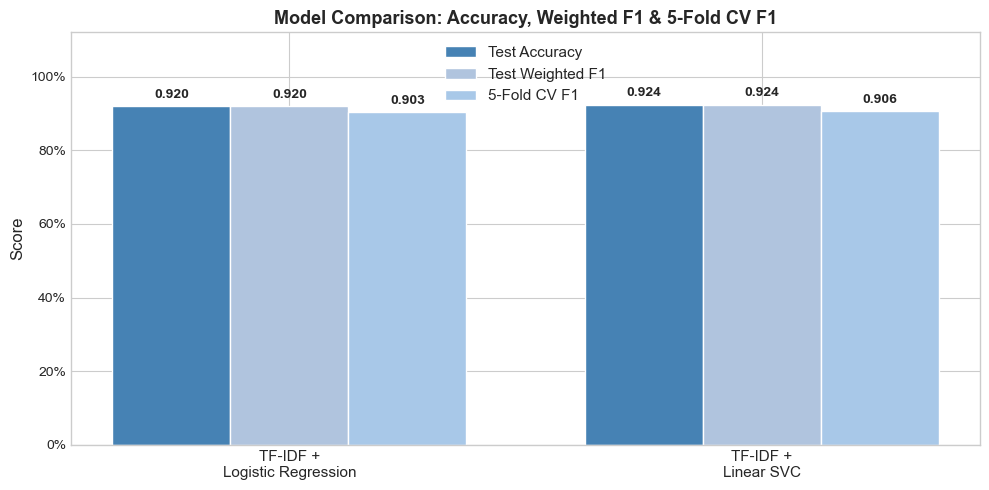

📈 Saved to outputs/model_comparison.png


In [12]:
models      = ['TF-IDF +\nLogistic Regression', 'TF-IDF +\nLinear SVC']
accuracies  = [acc_lr, acc_svc]
f1_scores   = [f1_lr,  f1_svc]
# [CHANGED v2] Added CV means to chart for more honest visual comparison
cv_means    = [cv_scores_lr.mean(), cv_scores_svc.mean()]

x = np.arange(len(models))
w = 0.25  # [CHANGED v2] narrowed bars to fit 3 groups

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w,   accuracies, w, label='Test Accuracy',    color='steelblue',      edgecolor='white')
b2 = ax.bar(x,       f1_scores,  w, label='Test Weighted F1', color='lightsteelblue', edgecolor='white')
b3 = ax.bar(x + w,   cv_means,   w, label='5-Fold CV F1',     color='#a8c8e8',        edgecolor='white')  # [CHANGED v2]

ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.12)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_title('Model Comparison: Accuracy, Weighted F1 & 5-Fold CV F1', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

for bar in list(b1) + list(b2) + list(b3):  # [CHANGED v2] added b3
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 6), textcoords='offset points',
                ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('📈 Saved to outputs/model_comparison.png')

---
## 🟦 Step 7C — Confusion Matrix

### Why this step?
Accuracy tells you how often the model is right overall. The confusion matrix tells you *where* it goes wrong. In a clinical context, this is crucial — confusing Orthopedic notes with Surgery notes is far less serious than confusing Cardiovascular notes with Neurology notes. The matrix reveals which specialties are hardest to distinguish and informs where the model needs improvement.

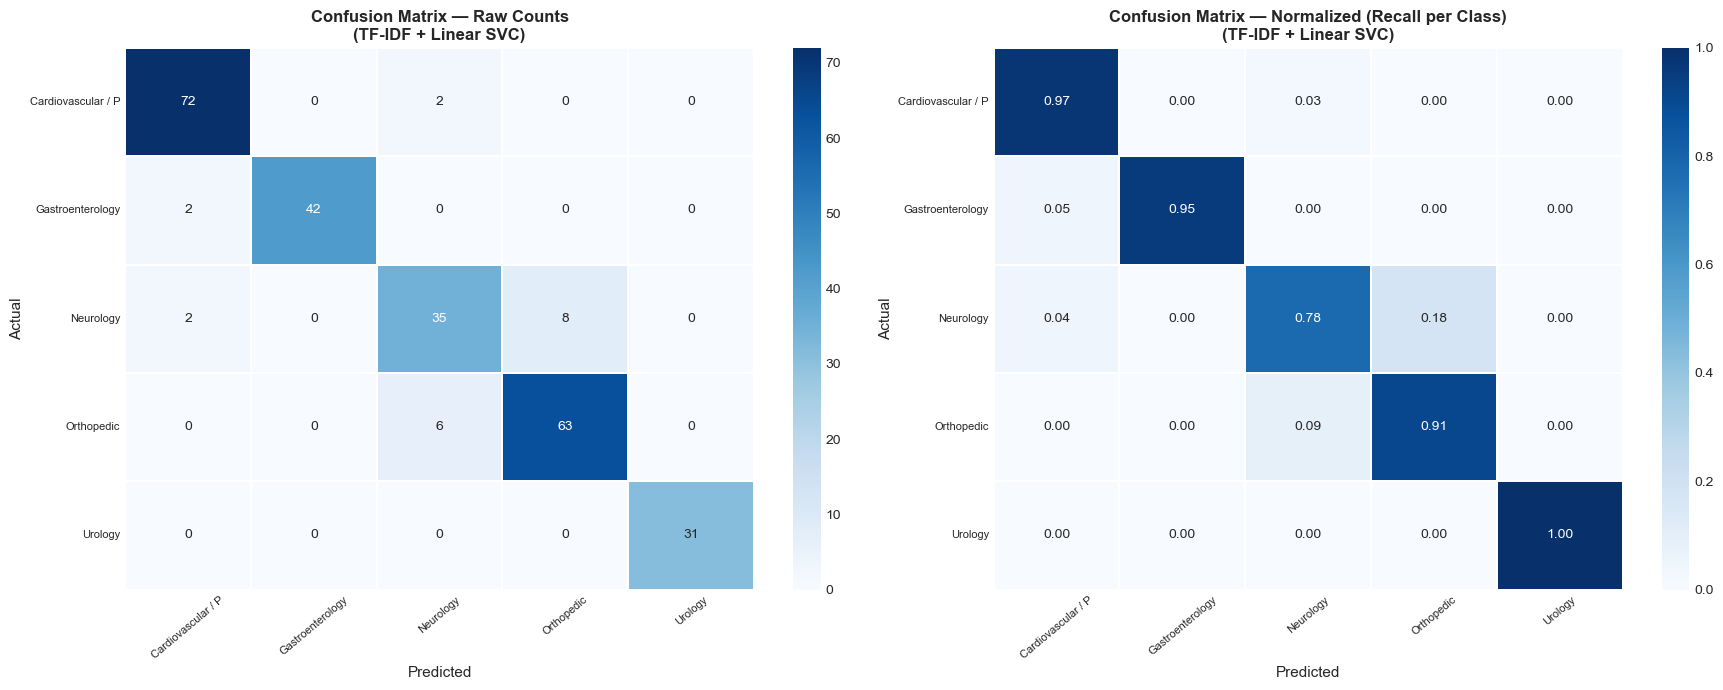

📈 Saved to outputs/confusion_matrix.png


In [13]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred_svc, labels=labels)

# Normalize by true label (row) for better readability
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[l[:18] for l in labels],
            yticklabels=[l[:18] for l in labels],
            ax=axes[0], linewidths=0.3)
axes[0].set_title('Confusion Matrix — Raw Counts\n(TF-IDF + Linear SVC)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted', fontsize=11)
axes[0].set_ylabel('Actual',    fontsize=11)
axes[0].tick_params(axis='x', rotation=40, labelsize=8)
axes[0].tick_params(axis='y', rotation=0,  labelsize=8)

# Normalized
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=[l[:18] for l in labels],
            yticklabels=[l[:18] for l in labels],
            ax=axes[1], linewidths=0.3, vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix — Normalized (Recall per Class)\n(TF-IDF + Linear SVC)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted', fontsize=11)
axes[1].set_ylabel('Actual',    fontsize=11)
axes[1].tick_params(axis='x', rotation=40, labelsize=8)
axes[1].tick_params(axis='y', rotation=0,  labelsize=8)

plt.tight_layout()
plt.savefig('../outputs/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('📈 Saved to outputs/confusion_matrix.png')

---
## 🔑 Step 7D — Top Predictive Terms per Specialty

### Why this step?
This is the most clinically interesting visualization in the project. By extracting the top TF-IDF coefficient weights from the Logistic Regression model, we can see exactly which words are most predictive of each specialty. As a physician, I can validate whether these terms make clinical sense — and they should. "Arthroscopy" and "meniscus" should top Orthopedics. "Catheterization" and "stent" should top Cardiovascular.

**Why this matters for model trust:** In healthcare AI, model interpretability is not optional — it is required for clinical adoption. Showing that the model has learned clinically meaningful terms (not statistical noise) builds trust with domain experts.

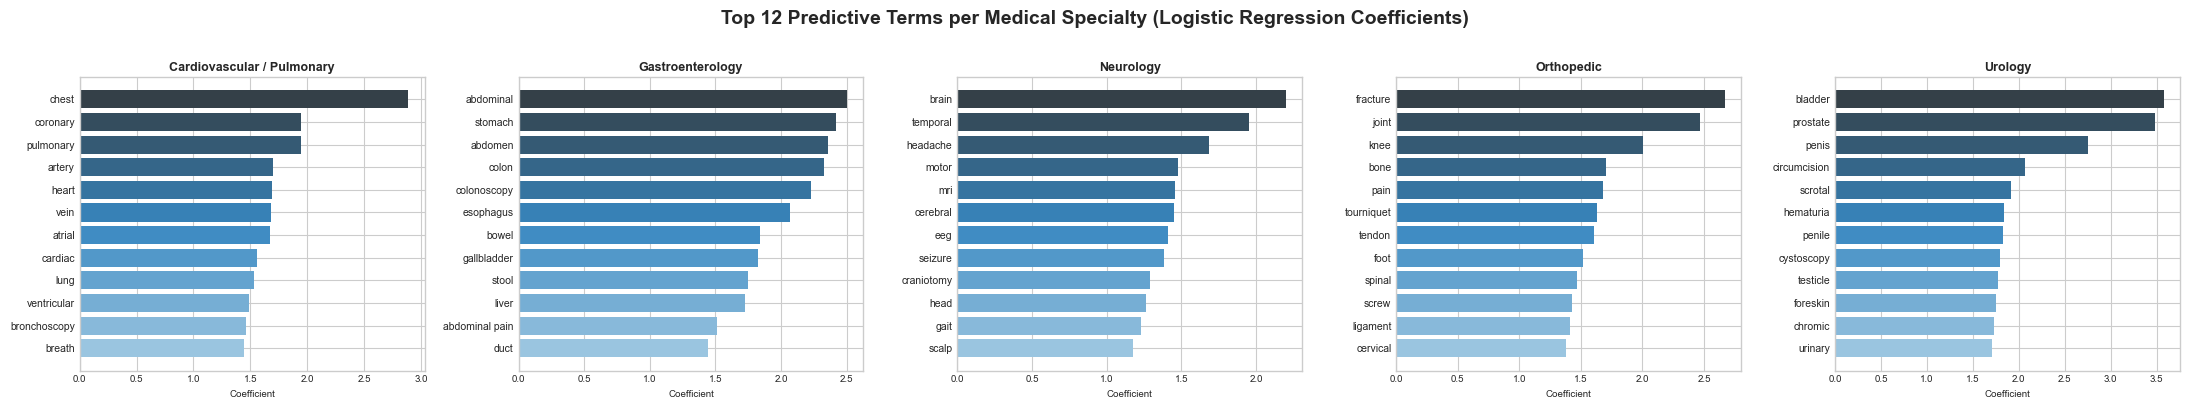

📈 Saved to outputs/top_terms_per_specialty.png


In [14]:
# Extract TF-IDF feature names and LR coefficients
tfidf_vocab  = lr_pipeline.named_steps['tfidf'].get_feature_names_out()
lr_clf       = lr_pipeline.named_steps['clf']
classes      = lr_clf.classes_

n_cols = 5
n_rows = int(np.ceil(len(classes) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, n_rows * 4))
axes = axes.flatten()

for i, (specialty, ax) in enumerate(zip(classes, axes)):
    top_idx     = lr_clf.coef_[i].argsort()[-12:][::-1]
    top_terms   = tfidf_vocab[top_idx]
    top_weights = lr_clf.coef_[i][top_idx]

    colors = sns.color_palette('Blues_d', 12)
    ax.barh(top_terms[::-1], top_weights[::-1], color=colors)
    ax.set_title(specialty[:28], fontsize=9, fontweight='bold', pad=4)
    ax.tick_params(axis='y', labelsize=7.5)
    ax.tick_params(axis='x', labelsize=7)
    ax.set_xlabel('Coefficient', fontsize=7)

# Hide unused subplots
for j in range(len(classes), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Top 12 Predictive Terms per Medical Specialty (Logistic Regression Coefficients)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/top_terms_per_specialty.png', dpi=150, bbox_inches='tight')
plt.show()
print('📈 Saved to outputs/top_terms_per_specialty.png')

---
## 🩺 Step 8 — Try It: Predict a New Clinical Note

In [15]:
def predict_specialty(note: str, pipeline=svc_pipeline) -> str:
    """Predict the medical specialty from a clinical note string."""
    clean = preprocess_clinical_text(note)
    return pipeline.predict([clean])[0]

# Test notes
test_notes = {
    'Cardiology note' : (
        "Patient presented with chest pain radiating to the left arm. ECG showed "
        "ST elevation. Troponin elevated. Coronary angiography revealed 95% occlusion "
        "of right coronary artery. PCI performed with stent placement."
    ),
    'Orthopedic note' : (
        "Patient complains of right knee pain after sports injury. MRI revealed "
        "anterior cruciate ligament tear and medial meniscus damage. Arthroscopic "
        "surgery recommended with ligament reconstruction."
    ),
    'Neurology note'  : (
        "Patient presented with sudden onset severe headache, photophobia, and neck "
        "stiffness. CT scan showed no hemorrhage. Lumbar puncture performed. "
        "Findings consistent with bacterial meningitis."
    ),
}

print('=' * 55)
print('SPECIALTY PREDICTION — SAMPLE NOTES')
print('=' * 55)
for label, note in test_notes.items():
    pred = predict_specialty(note)
    print(f'\n{label}:')
    print(f'  Note    : {note[:80]}...')
    print(f'  → Predicted: {pred}')

print('\n\n--- Try your own note ---')
my_note = "Patient presents with progressive memory loss, confusion, and difficulty in word finding."
print(f'My note    : {my_note}')
print(f'→ Predicted: {predict_specialty(my_note)}')

SPECIALTY PREDICTION — SAMPLE NOTES

Cardiology note:
  Note    : Patient presented with chest pain radiating to the left arm. ECG showed ST eleva...
  → Predicted: Cardiovascular / Pulmonary

Orthopedic note:
  Note    : Patient complains of right knee pain after sports injury. MRI revealed anterior ...
  → Predicted: Orthopedic

Neurology note:
  Note    : Patient presented with sudden onset severe headache, photophobia, and neck stiff...
  → Predicted: Neurology


--- Try your own note ---
My note    : Patient presents with progressive memory loss, confusion, and difficulty in word finding.
→ Predicted: Neurology


---
## 💾 Step 9 — Save Results Summary

In [16]:
results = pd.DataFrame({
    'Model'        : ['TF-IDF + Logistic Regression', 'TF-IDF + Linear SVC'],
    'Accuracy'     : [round(acc_lr,  4), round(acc_svc,  4)],
    'Weighted_F1'  : [round(f1_lr,   4), round(f1_svc,   4)],
    # [CHANGED v2] Added CV columns — single test split can be misleading
    'CV_F1_Mean'   : [round(cv_scores_lr.mean(), 4), round(cv_scores_svc.mean(), 4)],
    'CV_F1_Std'    : [round(cv_scores_lr.std(),  4), round(cv_scores_svc.std(),  4)],
    'Best'         : ['', '✓' if acc_svc >= acc_lr else '']
})

results.to_csv('../outputs/model_results_summary.csv', index=False)
print('✅ Results saved to outputs/model_results_summary.csv')
print()
print(results.to_string(index=False))

✅ Results saved to outputs/model_results_summary.csv

                       Model  Accuracy  Weighted_F1  CV_F1_Mean  CV_F1_Std Best
TF-IDF + Logistic Regression    0.9202       0.9198      0.9033     0.0243     
         TF-IDF + Linear SVC    0.9240       0.9236      0.9060     0.0239    ✓


---
## 🔭 Phase 2 — MIMIC-III Upgrade Path

> **[CHANGED v2]** PhysioNet credentialing has been approved ✅ — Phase 2 is now actively in progress.

This project upgrades to a much larger and more realistic dataset.
